In [1]:
# SPDX-License-Identifier: Apache-2.0 AND CC-BY-NC-4.0
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# http://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# Universal Sparse Tensor Exercises

This notebook introduces the UST (**Universal Sparse Tensor**) in nvmath-python.

Background material can be found in the blog postings:

 - [Establishing a scalable sparse ecosystem with the UST](https://developer.nvidia.com/blog/establishing-a-scalable-sparse-ecosystem-with-the-universal-sparse-tensor/)
 - [Simplify Sparse Deep Learning with UST in nvmath-python](https://developer.nvidia.com/blog/simplify-sparse-deep-learning-with-universal-sparse-tensor-in-nvmath-python/)

## Key Topics:

- Introduction to the UST in nvmath-python
- Zero-cost interoperability: data-movement-free conversion with e.g. CuPy
- Common and custom formats: define novel sparsity schemes
- Transparent caching: avoid JIT/LTO recompilation and replanning

## Key Insights:

- Decoupling a tensor’s sparsity from its memory storage representation
- DSL describes how a tensor should be represented in memory
- Developers focus on the sparsity of a tensor only

## Sparse Storage Formats in CuPY: DIA, CSR, COO

Before we look at the UST, let's first explore common sparse storage formats in CuPy.

In [2]:
import cupy as cp
import cupyx.scipy.sparse as sp

# Create a sparse matrix: tridiagonal matrix in DIA, CSR, and COO format.
n = 8
values = cp.array([[-1.0] * n, [4.0] * n, [1.0] * n], dtype=cp.float32)
offsets = cp.array([-1, 0, 1], dtype=cp.int32)
a_cp_dia = sp.dia_matrix((values, offsets), shape=(n, n))
a_cp_csr = sp.csr_matrix(a_cp_dia)
a_cp_coo = sp.coo_matrix(a_cp_dia)
    
a_cp_coo.sum_duplicates()   # coalesce COO format

You can explore the contents of each sparse storage format with a simple print statement. Let's look at the COO format below, which stores every nonzero as coordinate tuple and associated value.

In [3]:
print(a_cp_coo)

<COOrdinate sparse matrix of dtype 'float32'
	with 22 stored elements and shape (8, 8)>
  Coords	Values
  (0, 0)	4.0
  (0, 1)	1.0
  (1, 0)	-1.0
  (1, 1)	4.0
  (1, 2)	1.0
  (2, 1)	-1.0
  (2, 2)	4.0
  (2, 3)	1.0
  (3, 2)	-1.0
  (3, 3)	4.0
  (3, 4)	1.0
  (4, 3)	-1.0
  (4, 4)	4.0
  (4, 5)	1.0
  (5, 4)	-1.0
  (5, 5)	4.0
  (5, 6)	1.0
  (6, 5)	-1.0
  (6, 6)	4.0
  (6, 7)	1.0
  (7, 6)	-1.0
  (7, 7)	4.0


The DIA format and CSR format use different compaction schemes. No single sparse format is optimal for all cases; the best choice depends on the nonzero distribution, operations, and target architecture.

Having different sparse storage formats distracts from the actual coding effort. The UST addresses this by decoupling a tensor’s sparsity from its memory storage representation by using a domain-specific language (DSL) to describe how a tensor should be represented in memory. Developers focus on the sparsity of a tensor only.

## UST in nvmath-python

We have implemented this idea in an experimental part of nvmath-python. A fundamental design decision was to provide zero-cost interoperability between the UST and sparse storage formats in PyTorch, SciPy, and CuPy.

We can construct a UST view of the three sparse storage formats above as follows.

In [4]:
from nvmath.sparse.ust import Tensor

u_dia = Tensor.from_package(a_cp_dia)
u_csr = Tensor.from_package(a_cp_csr)
u_coo = Tensor.from_package(a_cp_coo)

Once we have a UST view, we can use all the built-in utilities such as printing and drawing.

For example, when we print the COO format, we see the familiar coordinate tuples (in crd) and values (in values). The format is a DSL description of the COO format.

You can change the print statement below to print the other two formats and see how the DSL changes.

In [5]:
print(u_coo)


---- Sparse Tensor<VAL=float32,POS=int32,CRD=int32,DIM=2,LVL=2>
format   : [i, j] -> (i: (<LevelFormat.COMPRESSED>, <LevelProperty.NONUNIQUE>), j: <LevelFormat.SINGLETON>)
device   : cuda
dim      : [8, 8]
lvl      : [8, 8]
nse      : 22
pos[0]   : [0, 22] #2
crd[0]   : [0, 0, 1, 1, 1, 2, 2, 2, 3, 3, 3, 4, 4, 4, 5, 5, 5, 6, 6, 6, 7, 7] #22
crd[1]   : [0, 1, 0, 1, 2, 1, 2, 3, 2, 3, 4, 3, 4, 5, 4, 5, 6, 5, 6, 7, 6, 7] #22
values   : [4.0, 1.0, -1.0, 4.0, 1.0, -1.0, 4.0, 1.0, -1.0, 4.0, 1.0, -1.0, 4.0, 1.0, -1.0, 4.0, 1.0, -1.0, 4.0, 1.0, -1.0, 4.0] #22
data     : 272 bytes
sparsity : 65.62%
----


We can also draw the nonzero structure directly as follows.

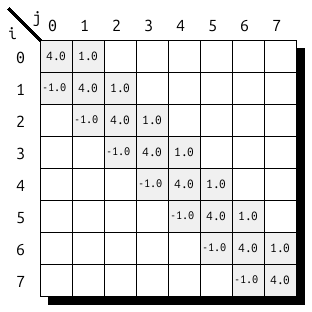

In [6]:
u_coo.draw()

And we can also show the storage contents directly. Try this for the other formats as well to see how storage differs.

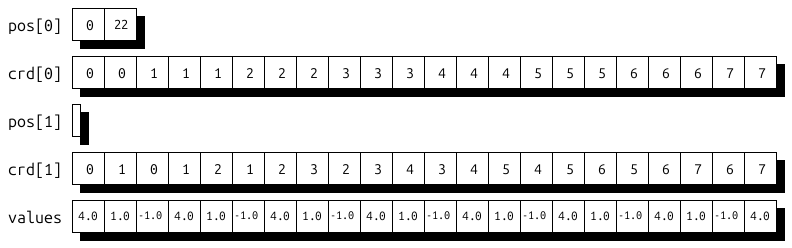

In [7]:
u_coo.draw_storage()

## Stateful API for generic matmul with UST

The UST also supports the Stateful APIs for generic matrix multiplication introduced earlier today, where we perform the specification and planning once and amortize their cost through multiple executions. For the UST, the planning also involves determining whether a library implementation is available (the fast-path, i.e. SpMV on CSR is available using cuSPARSE), or whether on-the-fly code generation must be used for cases that lack direct library support (the slow-path, requires JIT/LTO of the new code). Note that the results of JIT/LTO-ing a new kernel (which can have a large cost) are cached between planning phases, so that you only pay the compilation time for a particular format once (making subsequent planning phases take the fast-path again).


Let's first run a SpMV using CuPy and using UST nvmath-python.

In [8]:
cp_ones = cp.ones((n,), dtype=cp.float32)

In [9]:
# Use CuPy SpMV
a_cp_coo @ cp_ones

array([5., 4., 4., 4., 4., 4., 4., 3.], dtype=float32)

In [10]:
from nvmath.sparse.generic import Matmul

# Use UST SpMV
cp_out = cp.zeros((n,), dtype=cp.float32)
u_ones = Tensor.from_package(cp_ones)
u_out = Tensor.from_package(cp_out)

# Stateful API for generic matmul. Involves planning and execution phase, where planning costs can be amortized over many executions.
# In addition, a JIT/LTO for a novel format is cached even between different planning phases (assuming the format is the same).
with Matmul(u_csr, u_ones, u_out) as mm:
    mm.plan()
    mm.execute()

print(u_out.to_package())   # proper way to change the UST view back to CuPy land
print(cp_out)               # however, remember that UST is simply a view into cp_out


[5. 4. 4. 4. 4. 4. 4. 3.]
[5. 4. 4. 4. 4. 4. 4. 3.]


## Benchmark CuPY DIA/CSR/COO with UST DIA/CSR/COO

Now, let's benchmark this. First we make the matrices larger to get meaningful measurements.

In [11]:
n = 1024 * 32
values = cp.array([[0.0] + [-1.0] * (n - 1), [4.0] * n, [1.0] * (n - 1) + [0.0]], dtype=cp.float32)
offsets = cp.array([-1, 0, 1], dtype=cp.int32)
a_cp_dia = sp.dia_matrix((values, offsets), shape=(n, n))
a_cp_csr = sp.csr_matrix(a_cp_dia)
a_cp_coo = sp.coo_matrix(a_cp_dia)
a_cp_coo.sum_duplicates()   # coalesce COO format

cp_ones = cp.ones((n,), dtype=cp.float32)
cp_out = cp.zeros((n,), dtype=cp.float32)

u_dia = Tensor.from_package(a_cp_dia)
u_csr = Tensor.from_package(a_cp_csr)
u_coo = Tensor.from_package(a_cp_coo)
u_ones = Tensor.from_package(cp_ones)
u_out = Tensor.from_package(cp_out)

Then we benchmark CuPy.

In [12]:
from cupyx.profiler import benchmark

def matmul(a, x):
    return a @ x

cupy1 = benchmark(matmul, (a_cp_dia, cp_ones), n_repeat=10)
cupy2 = benchmark(matmul, (a_cp_csr, cp_ones), n_repeat=10)
cupy3 = benchmark(matmul, (a_cp_coo, cp_ones), n_repeat=10)

print(cupy1)
print(cupy2)
print(cupy3)    

matmul              :    CPU:   406.469 us   +/- 57.279 (min:   353.861 / max:   548.591) us     GPU-0:   438.554 us   +/- 108.690 (min:   356.352 / max:   716.800) us
matmul              :    CPU:    23.118 us   +/-  1.004 (min:    21.885 / max:    25.681) us     GPU-0:    28.762 us   +/-  0.968 (min:    27.648 / max:    30.720) us
matmul              :    CPU:  1373.629 us   +/- 325.097 (min:  1251.831 / max:  2347.397) us     GPU-0:  1600.877 us   +/- 405.690 (min:  1451.008 / max:  2817.024) us


Then we benchmark UST.

In [13]:
with Matmul(u_dia, u_ones, u_out) as mm:
    mm.plan()
    ust1 = benchmark(mm.execute, n_repeat=10)
    
with Matmul(u_csr, u_ones, u_out) as mm:
    mm.plan()
    ust2 = benchmark(mm.execute, n_repeat=10)    
    
with Matmul(u_coo, u_ones, u_out) as mm:
    mm.plan()
    ust3 = benchmark(mm.execute, n_repeat=10)

print(ust1)
print(ust2)
print(ust3)   


==> Compiling matmul

<== Compiled matmul in   29884.67 us.

execute             :    CPU:     9.484 us   +/-  0.246 (min:     9.168 / max:     9.937) us     GPU-0:    10.947 us   +/-  0.336 (min:    10.240 / max:    11.296) us
execute             :    CPU:     9.274 us   +/-  0.695 (min:     8.446 / max:    10.997) us     GPU-0:    15.197 us   +/-  0.784 (min:    14.336 / max:    17.184) us
execute             :    CPU:     7.996 us   +/-  0.587 (min:     7.198 / max:     9.317) us     GPU-0:    11.139 us   +/-  0.871 (min:     9.984 / max:    13.312) us


And finally we plot the results.

Note how UST DIA format performs best, since it JIT compiles into a tailored kernel for that format. The UST COO outperforms CuPy COO by far (something the CuPy team could look into). The UST CSR slightly outperforms CuPy CSR, even though both use cuSPARSE as backend, simply because nvmath-python provides the plan-execute setup.

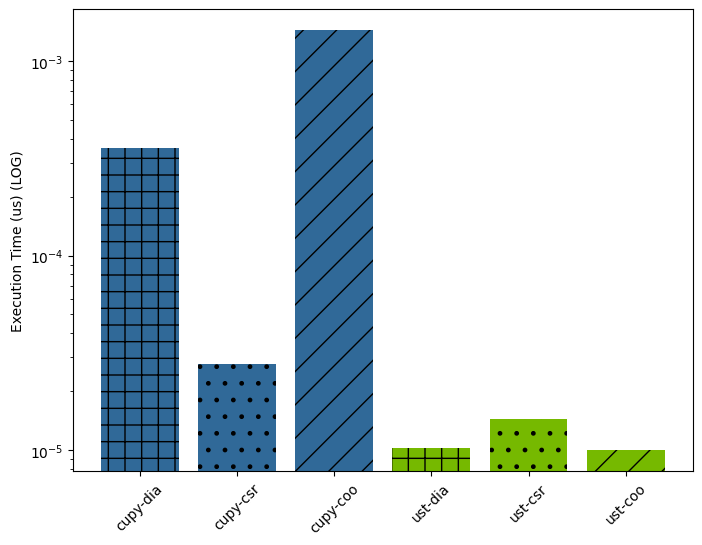

In [14]:
import matplotlib.pyplot as plt

labels = ["cupy-dia", "cupy-csr", "cupy-coo", "ust-dia", "ust-csr", "ust-coo"]
runtimes = [
    min(cupy1.gpu_times[0]),
    min(cupy2.gpu_times[0]),
    min(cupy3.gpu_times[0]),
    min(ust1.gpu_times[0]),
    min(ust2.gpu_times[0]),
    min(ust3.gpu_times[0]),
]
bar_colors = ["#306998", "#306998", "#306998", "#76B900", "#76B900", "#76B900"]
hatch = ["+", ".", "/", "+", ".", "/"]

plt.figure(figsize=(8, 6))
plt.bar(labels, runtimes, color=bar_colors, hatch=hatch)
plt.ylabel("Execution Time (us) (LOG)")
plt.yscale("log")
plt.xticks(rotation=45)

plt.show()

## Amortization of Planning Cost (even for expensive one-time JIT/LTO)

So far, we have compared the regular execution time of CuPy with the execution time of nvmath-python *after* planning. This is a fair comparison for cases where a single planning phase is followed by many subsequent executions. However, for a fair comparison, below we plot the CuPy DIA performance against the UST DIA performance for a completely cold cache planning phase. A full JIT/LTO compilation of a novel kernel can easily take 25000us (it is hard to measure exactly in this notebook because this is done only once, even between new planning phases; also, typically the planning phase is much cheaper, since it often can use the cuSPARSE library directly). To show a typical worst-case when the amortization must be taken into account, below we plot the measured CuPy DIA against the measure UST DIA performance using a hard-coded overhead (you can change this to see the differences). The plot now shows how many iterations are required to fully benefit from the UST when planning time is at a premium as well.


0.00035635200142860414 vs 0.024999999999999998 1.0239999741315842e-05


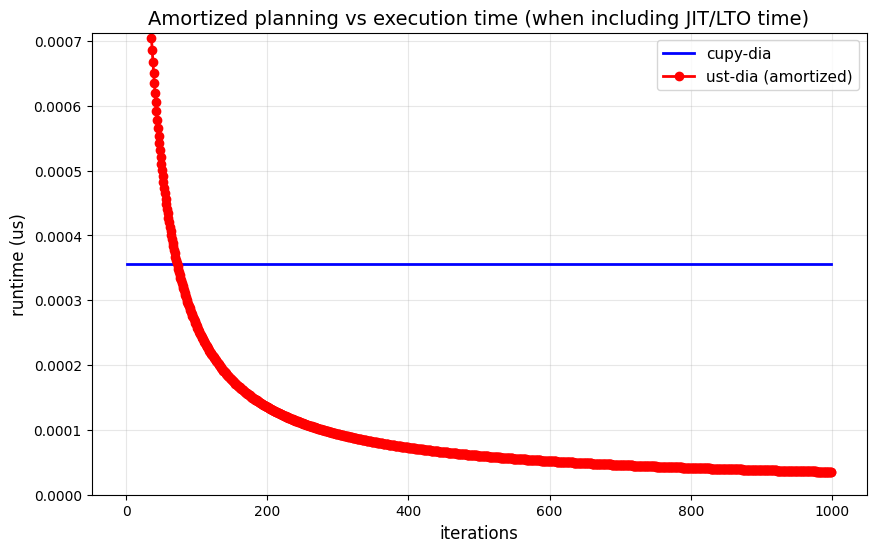

In [15]:
import numpy as np

cupy_dia = min(cupy1.gpu_times[0])
ust_dia = min(ust1.gpu_times[0])
planning_time = 25000  * 1e-6   # put JIT/LTO estimate here
print(cupy_dia, 'vs', planning_time, ust_dia)

i_values = np.arange(1, 1000)
values1 = np.full_like(i_values, cupy_dia, dtype=float)
values2 = ust_dia + planning_time / i_values

plt.figure(figsize=(10, 6))
plt.plot(i_values, values1, 'b-', linewidth=2, label="cupy-dia")
plt.plot(i_values, values2, 'r-', marker='o', linewidth=2, markersize=6, label="ust-dia (amortized)")
plt.xlabel('iterations', fontsize=12)
plt.ylabel('runtime (us)', fontsize=12)
plt.ylim(0, 2*cupy_dia)  # pick a region that puts the constant cupy_dia in the middle
plt.title("Amortized planning vs execution time (when including JIT/LTO time)", fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

## Novel Formats

Besides supporting common sparse storage formats, the DSL of the UST allows for defining your own nifty new format, and all prior operations (like matmul) work out of the box using the JITted codegen path when no library support exists. Various less common sparse storage formats are already pre-defined the NamedFormats class (but you can also design your own by learning the DSL).

In [16]:
from nvmath.sparse.ust import NamedFormats

print(NamedFormats.COO)
print(NamedFormats.CSR)
print(NamedFormats.CSC)
print(NamedFormats.DCSR)
print(NamedFormats.DCSC)
print(NamedFormats.BSRRight((8,8)))
print(NamedFormats.BSCRight((8,8)))

[i, j] -> (i: (<LevelFormat.COMPRESSED>, <LevelProperty.NONUNIQUE>), j: <LevelFormat.SINGLETON>)
[i, j] -> (i: <LevelFormat.DENSE>, j: <LevelFormat.COMPRESSED>)
[i, j] -> (j: <LevelFormat.DENSE>, i: <LevelFormat.COMPRESSED>)
[i, j] -> (i: <LevelFormat.COMPRESSED>, j: <LevelFormat.COMPRESSED>)
[i, j] -> (j: <LevelFormat.COMPRESSED>, i: <LevelFormat.COMPRESSED>)
[i, j] -> ((i // 8): <LevelFormat.DENSE>, (j // 8): <LevelFormat.COMPRESSED>, (i % 8): <LevelFormat.DENSE>, (j % 8): <LevelFormat.DENSE>)
[i, j] -> ((j // 8): <LevelFormat.DENSE>, (i // 8): <LevelFormat.COMPRESSED>, (i % 8): <LevelFormat.DENSE>, (j % 8): <LevelFormat.DENSE>)


An existing UST can be converted into any of these formats with the following conversion call (note that this is no longer a zero-cost operation, since data needs to be reshuffled; also, the current conversion implementation is a prototype, and can be rather costly).

In [17]:
u_block = u_coo.convert(tensor_format=NamedFormats.BSRRight((8, 8)))
print(u_block)

---- Sparse Tensor<VAL=float32,POS=int32,CRD=int32,DIM=2,LVL=4>
format   : [i, j] -> ((i // 8): <LevelFormat.DENSE>, (j // 8): <LevelFormat.COMPRESSED>, (i % 8): <LevelFormat.DENSE>, (j % 8): <LevelFormat.DENSE>)
device   : cuda
dim      : [32768, 32768]
lvl      : [4096, 4096, 8, 8]
nse      : 786304
pos[0]   : [] #0
pos[1]   : [0, 2, 5, 8, 11, 14, 17, 20, 23, 26, 29, 32, 35, 38, 41, 44, 47, 50, 53, 56, 59, 62, 65, 68, 71, 74, 77, 80, 83, 86, 89, 92, ..., 12194, 12197, 12200, 12203, 12206, 12209, 12212, 12215, 12218, 12221, 12224, 12227, 12230, 12233, 12236, 12239, 12242, 12245, 12248, 12251, 12254, 12257, 12260, 12263, 12266, 12269, 12272, 12275, 12278, 12281, 12284, 12286] #4097
pos[2]   : [] #0
pos[3]   : [] #0
crd[0]   : [] #0
crd[1]   : [0, 1, 0, 1, 2, 1, 2, 3, 2, 3, 4, 3, 4, 5, 4, 5, 6, 5, 6, 7, 6, 7, 8, 7, 8, 9, 8, 9, 10, 9, 10, 11, ..., 4084, 4085, 4086, 4085, 4086, 4087, 4086, 4087, 4088, 4087, 4088, 4089, 4088, 4089, 4090, 4089, 4090, 4091, 4090, 4091, 4092, 4091, 4092, 4093

## Exercise

Convert the UST for u_coo to DCSR and perform the matmul benchmark on this new format. Compare the performance with the UST implementation of the other three formats shown earlier (and keep in mind that this uses a new JIT/LTO kernel, since no backend library supports the doubly-compressed format).

In [18]:
u_dcsr = u_coo.convert(tensor_format=NamedFormats.DCSR)

In [19]:
with Matmul(u_dcsr, u_ones, u_out) as mm:
    mm.plan()
    ust4 = benchmark(mm.execute, n_repeat=10)

print(ust4)


==> Compiling matmul

<== Compiled matmul in   24961.27 us.

execute             :    CPU:     9.027 us   +/-  0.271 (min:     8.688 / max:     9.532) us     GPU-0:    10.557 us   +/-  0.632 (min:    10.208 / max:    12.288) us


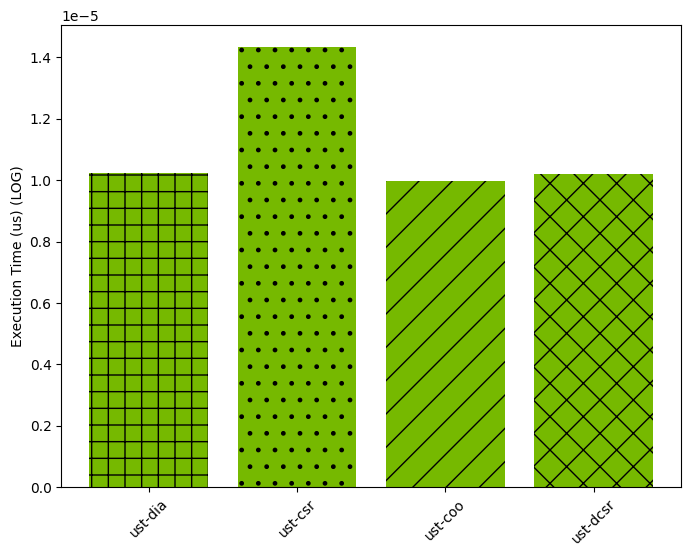

In [20]:
labels = ["ust-dia", "ust-csr", "ust-coo", "ust-dcsr"]
runtimes = [
    min(ust1.gpu_times[0]),
    min(ust2.gpu_times[0]),
    min(ust3.gpu_times[0]),
    min(ust4.gpu_times[0]),
]
bar_colors = ["#76B900", "#76B900", "#76B900", "#76B900"]
hatch = ["+", ".", "/", "x"]

plt.figure(figsize=(8, 6))
plt.bar(labels, runtimes, color=bar_colors, hatch=hatch)
plt.ylabel("Execution Time (us) (LOG)")
plt.xticks(rotation=45)

plt.show()


## Conclusion

Even though we could not cover all details in this notebook, hopefully the material presented here has piqued your interest into learning more about the Universal Sparse Tensor!